In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn.metrics as metrics
import sklearn.datasets

In [2]:
house = pd.read_csv('train.csv')

In [3]:
print(house.head())

   ID     crim    zn  indus  chas    nox     rm   age     dis  rad  tax  \
0   1  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296   
1   2  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242   
2   4  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222   
3   5  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222   
4   7  0.08829  12.5   7.87     0  0.524  6.012  66.6  5.5605    5  311   

   ptratio   black  lstat  price  
0     15.3  396.90   4.98   24.0  
1     17.8  396.90   9.14   21.6  
2     18.7  394.63   2.94   33.4  
3     18.7  396.90   5.33   36.2  
4     15.2  395.60  12.43   22.9  


In [4]:
house.shape

(333, 15)

In [5]:
house.isnull().sum()

ID         0
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
black      0
lstat      0
price      0
dtype: int64

In [6]:

house.describe()

,ID,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,price
count,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000
mean,250.951952,3.360341,10.689189,11.293483,0.060060,0.557144,6.265619,68.226426,3.709934,9.633634,409.279279,18.448048,359.466096,12.515435,22.768769
std,147.859438,7.352272,22.674762,6.998123,0.237956,0.114955,0.703952,28.133344,1.981123,8.742174,170.841988,2.151821,86.584567,7.067781,9.173468
min,1.000000,0.006320,0.000000,0.740000,0.000000,0.385000,3.561000,6.000000,1.129600,1.000000,188.000000,12.600000,3.500000,1.730000,5.000000
25%,123.000000,0.078960,0.000000,5.130000,0.000000,0.453000,5.884000,45.400000,2.122400,4.000000,279.000000,17.400000,376.730000,7.180000,17.400000
50%,244.000000,0.261690,0.000000,9.900000,0.000000,0.538000,6.202000,76.700000,3.092300,5.000000,330.000000,19.000000,392.050000,10.970000,21.600000
75%,377.000000,3.678220,12.500000,18.100000,0.000000,0.631000,6.595000,93.800000,5.116700,24.000000,666.000000,20.200000,396.240000,16.420000,25.000000
max,506.000000,73.534100,100.000000,27.740000,1.000000,0.871000,8.725000,100.000000,10.710300,24.000000,711.000000,21.200000,396.900000,37.970000,50.000000


In [7]:
correlation_data = house.corr()

<Axes: >

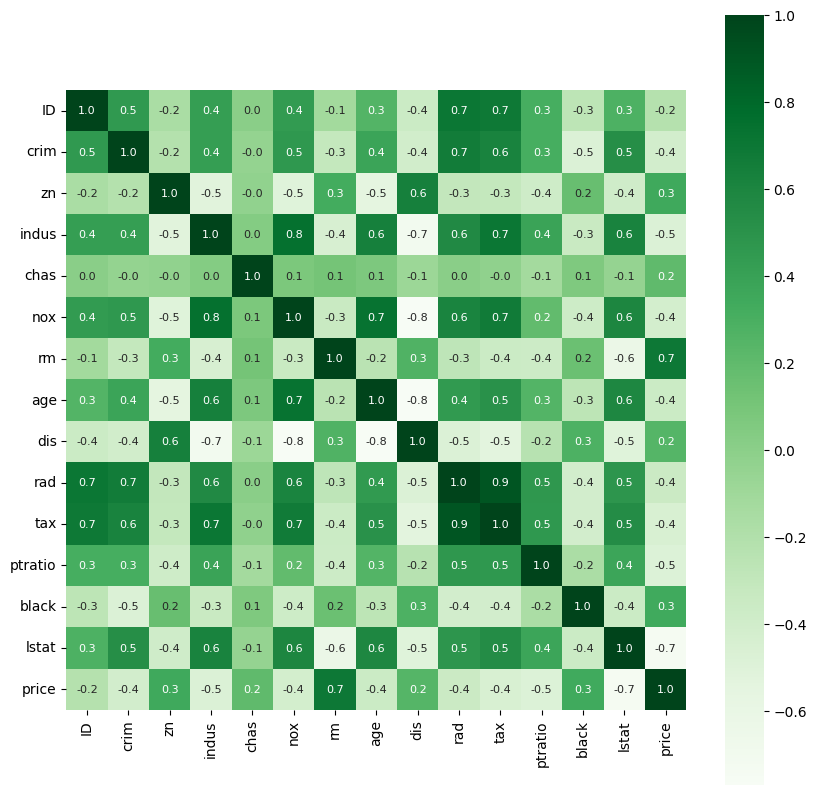

In [10]:
plt.figure(figsize=(10,10))
sns.heatmap(correlation_data, cbar=True, square=True, fmt=".1f", annot=True, annot_kws={"size":8}, cmap="Greens")

In [13]:
x = house.drop(['ID','price'], axis=1)
y = house['price']


In [ ]:
print(x.head())
print(y.head())

0    24.0
1    21.6
2    33.4
3    36.2
4    22.9
Name: price, dtype: float64


In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [17]:
model = xgb.XGBRegressor()
model.fit(x_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [18]:
training_pred = model.predict(x_train)

In [19]:
print(training_pred)

[19.00726   19.203173  14.103557  14.796538  25.298388  13.299554
 20.094099  24.994976  30.998638  20.300964  22.697983  22.601896
 27.501606  17.404343  24.10004   48.799706  18.398596  12.001338
  9.699363  19.70273   17.705963  32.399376  17.599918  17.802355
 20.598953  24.403673  22.501326  23.603018  15.200121  18.901447
 19.391142  17.103281  19.400911  30.801016  10.501652  17.799646
 22.901554  43.09887   19.902103  18.697712  16.498833  21.999615
 44.800827  18.698519  23.192364  17.000395  37.6034    22.29788
 24.300163  29.901423  23.902718  21.402828  16.21012   12.702906
 23.902554  16.299643  32.900673  14.506314  17.500528  17.404596
 20.399849  18.596607  22.10545   14.398659  13.40092   20.299768
 26.504015  34.897705  31.598074  49.99986   27.491205  17.199764
 24.384315  37.200356  20.703348  15.70222    8.700748  30.086796
 12.79619   23.700571  14.100736  20.799736  19.497715  31.500698
 19.801498  32.500515  23.297655  22.597927  28.39968   22.19741
 24.997154  

In [20]:
score1 = metrics.r2_score(y_train, training_pred)

score2 = metrics.mean_absolute_error(y_train, training_pred)

print("R2 score: ", score1)
print("MAE score: ", score2)

R2 score:  0.9999998510723442
MAE score:  0.002371523434058252


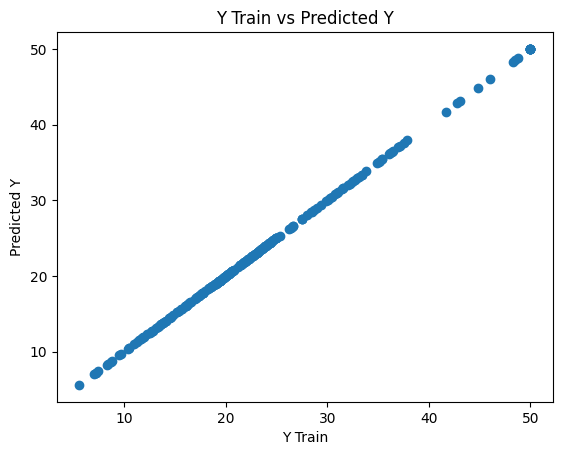

In [22]:
plt.scatter(y_train, training_pred)
plt.xlabel("Y Train")
plt.ylabel("Predicted Y")
plt.title("Y Train vs Predicted Y")
plt.show()

In [21]:
test_data_pred = model.predict(x_test)
score3 = metrics.r2_score(y_test, test_data_pred)
score4 = metrics.mean_absolute_error(y_test, test_data_pred)
print("R2 score: ", score3)
print("MAE score: ", score4)

R2 score:  0.9073458394140619
MAE score:  1.8933493913109625
